In [ ]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import (
    WeightedRandomSampler,
    DataLoader,
    Subset
)
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from src.models import create_resnet18_layer4
from src.data import set_seed, create_dataloaders
from src.train import train_model

from src.augmentations import (
    augmentation_list,
    augmentation_count,
    eval_transform
)

ModuleNotFoundError: No module named 'models'

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


In [ ]:
train_path = "dataset/CROP+MERGED/train"

In [ ]:
seeds = [42, 10, 20]

results = []


for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        set_seed(seed)

        train_loader, val_loader = create_dataloaders(
            train_path=train_path,
            train_transform=train_transform,
            eval_transform=eval_transform,
            batch_size=32
        )

        model = create_resnet18_layer4(
            num_classes=8
        )

        best_val_accuracy, best_model_state = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=150,
            patience=20,
            layer4_lr=0.0001,
            classifier_lr=0.001
        )

        results.append({
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count":
                augmentation_count[augmentation_name],
            "model_state": best_model_state
        })

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_result = results[0]


for result in results:

    if (
        result["best_val_accuracy"]
        > best_result["best_val_accuracy"]
    ):

        best_result = result

    elif (
        result["best_val_accuracy"]
        == best_result["best_val_accuracy"]
    ):

        if (
            result["augmentation_count"]
            > best_result["augmentation_count"]
        ):

            best_result = result


print("\n" + "=" * 70)
print("ALL RESULTS")
print("=" * 70)


for result in results:

    print(
        f"{result['augmentation']:25s} | "
        f"Seed: {result['seed']} | "
        f"Val: "
        f"{result['best_val_accuracy'] * 100:.2f}% | "
        f"Augmentations: "
        f"{result['augmentation_count']}"
    )


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    f"Augmentation: "
    f"{best_result['augmentation']}"
)

print(
    f"Seed: "
    f"{best_result['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_result['best_val_accuracy'] * 100:.2f}%"
)

print(
    f"Number of Augmentations: "
    f"{best_result['augmentation_count']}"
)


torch.save(
    best_result["model_state"],
    "BEST_MODEL_Cleaned_Dataset.pth"
)

print(
    "\nBEST_MODEL_Cleaned_Dataset.pth "
    "saved successfully."
)

In [2]:
dataset_path = "dataset/merged_dataset"

train_path = dataset_path + "/train"
test_path = "dataset/test"


In [3]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    num_epochs=100,
    patience=15
):

    model = model.to(device)

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_f1 = -float("inf")
    best_model_state = None

    patience_counter = 0

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = correct / total


        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        val_labels = []
        val_predictions = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (
                    predicted == labels
                ).sum().item()

                val_labels.extend(
                    labels.cpu().numpy()
                )

                val_predictions.extend(
                    predicted.cpu().numpy()
                )

        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total


        # =========================
        # VALIDATION MACRO F1
        # =========================

        val_f1 = f1_score(
            val_labels,
            val_predictions,
            average="macro",
            zero_division=0
        )


        # =========================
        # SAVE HISTORY
        # =========================

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)


        # =========================
        # SCHEDULER
        # =========================

        if scheduler is not None:

            scheduler.step(val_f1)


        # =========================
        # BEST MODEL
        # =========================

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1


        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )


        # =========================
        # EARLY STOPPING
        # =========================

        if patience_counter >= patience:

            print("Early stopping.")

            break


    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }

    return model, history

In [4]:
def evaluate_validation(
    model,
    val_loader,
    class_names
):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    macro_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    report = classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    recalls = {
        cls: report[cls]["recall"]
        for cls in class_names
    }

    precisions = {
        cls: report[cls]["precision"]
        for cls in class_names
    }

    lowest_recall_class = min(
        recalls,
        key=recalls.get
    )

    lowest_precision_class = min(
        precisions,
        key=precisions.get
    )

    return {
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "report": report,
        "lowest_recall_class": lowest_recall_class,
        "lowest_precision_class": lowest_precision_class
    }

In [5]:
train_transform = transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

In [6]:
full_train_dataset = datasets.ImageFolder(
    train_path,
    transform=None
)

class_names = full_train_dataset.classes
labels = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    train_path,
    transform=test_transform
)

train_dataset = Subset(
    train_dataset,
    train_indices
)

val_dataset = Subset(
    val_dataset,
    val_indices
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
print("Train:", len(train_dataset))
print('Val:',len(val_dataset))
print("Test:", len(test_dataset))

Train: 2949
Val: 738
Test: 400


In [8]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 150, 150])
Labels shape: torch.Size([32])


In [9]:
class CNN(nn.Module):

    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 18 * 18, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [10]:
baseline_model = CNN(
    num_classes=8
).to(device)

baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

baseline_model, baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    baseline_criterion,
    baseline_optimizer,
    scheduler=None,
    num_epochs=100,
    patience=15
)

baseline_result = evaluate_validation(
    baseline_model,
    val_loader,
    class_names
)

Epoch [1/100] Train Loss: 3.7536 | Train Acc: 0.1831 | Val Loss: 1.8712 | Val Acc: 0.2371 | Val F1: 0.1736
Epoch [2/100] Train Loss: 2.0211 | Train Acc: 0.1970 | Val Loss: 1.8326 | Val Acc: 0.2981 | Val F1: 0.2438
Epoch [3/100] Train Loss: 1.9444 | Train Acc: 0.2126 | Val Loss: 1.7914 | Val Acc: 0.3035 | Val F1: 0.2258
Epoch [4/100] Train Loss: 1.9257 | Train Acc: 0.2336 | Val Loss: 1.7764 | Val Acc: 0.2886 | Val F1: 0.2410
Epoch [5/100] Train Loss: 1.8818 | Train Acc: 0.2547 | Val Loss: 1.7868 | Val Acc: 0.3225 | Val F1: 0.2340
Epoch [6/100] Train Loss: 1.8331 | Train Acc: 0.2662 | Val Loss: 1.6199 | Val Acc: 0.3238 | Val F1: 0.2107
Epoch [7/100] Train Loss: 1.7728 | Train Acc: 0.2706 | Val Loss: 1.6541 | Val Acc: 0.3049 | Val F1: 0.2231
Epoch [8/100] Train Loss: 1.7622 | Train Acc: 0.2828 | Val Loss: 1.5271 | Val Acc: 0.3279 | Val F1: 0.2549
Epoch [9/100] Train Loss: 1.7421 | Train Acc: 0.2781 | Val Loss: 1.4729 | Val Acc: 0.3808 | Val F1: 0.3086
Epoch [10/100] Train Loss: 1.7076 | T

In [11]:
train_targets = np.array(
    full_train_dataset.targets
)[train_indices]

class_counts = np.bincount(
    train_targets,
    minlength=num_classes
)

class_weights = np.zeros(num_classes, dtype=np.float64)
nonzero_classes = class_counts > 0
class_weights[nonzero_classes] = 1.0 / class_counts[nonzero_classes]

sample_weights = class_weights[
    train_targets
]

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

balanced_train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=0
)


In [12]:
balanced_model = CNN(
    num_classes=8
).to(device)

balanced_criterion = nn.CrossEntropyLoss()

balanced_optimizer = torch.optim.Adam(
    balanced_model.parameters(),
    lr=0.001
)

balanced_model, balanced_history = train_model(
    balanced_model,
    balanced_train_loader,
    val_loader,
    balanced_criterion,
    balanced_optimizer,
    scheduler=None,
    num_epochs=100,
    patience=15
)

balanced_result = evaluate_validation(
    balanced_model,
    val_loader,
    class_names
)

Epoch [1/100] Train Loss: 3.4460 | Train Acc: 0.1258 | Val Loss: 2.0797 | Val Acc: 0.1260 | Val F1: 0.0282
Epoch [2/100] Train Loss: 2.0807 | Train Acc: 0.1258 | Val Loss: 2.0777 | Val Acc: 0.1396 | Val F1: 0.0540
Epoch [3/100] Train Loss: 2.0797 | Train Acc: 0.1333 | Val Loss: 2.0792 | Val Acc: 0.1274 | Val F1: 0.0282
Epoch [4/100] Train Loss: 2.0776 | Train Acc: 0.1278 | Val Loss: 2.0524 | Val Acc: 0.1558 | Val F1: 0.0715
Epoch [5/100] Train Loss: 2.0739 | Train Acc: 0.1302 | Val Loss: 2.0800 | Val Acc: 0.1274 | Val F1: 0.0282
Epoch [6/100] Train Loss: 2.0798 | Train Acc: 0.1194 | Val Loss: 2.0797 | Val Acc: 0.1233 | Val F1: 0.0274
Epoch [7/100] Train Loss: 2.0800 | Train Acc: 0.1241 | Val Loss: 2.0794 | Val Acc: 0.1274 | Val F1: 0.0283
Epoch [8/100] Train Loss: 2.0791 | Train Acc: 0.1136 | Val Loss: 2.0795 | Val Acc: 0.1369 | Val F1: 0.0331
Epoch [9/100] Train Loss: 2.0793 | Train Acc: 0.1248 | Val Loss: 2.0900 | Val Acc: 0.1477 | Val F1: 0.0521
Epoch [10/100] Train Loss: 2.0798 | T

In [13]:
class BCELossForMultiClass(nn.Module):

    def __init__(self):
        super().__init__()

        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, outputs, labels):

        labels = torch.nn.functional.one_hot(
            labels,
            num_classes=outputs.size(1)
        ).float()

        return self.loss(
            outputs,
            labels
        )

In [14]:
bce_model = CNN(
    num_classes=8
).to(device)

bce_criterion = BCELossForMultiClass()

bce_optimizer = torch.optim.Adam(
    bce_model.parameters(),
    lr=0.001
)

bce_model, bce_history = train_model(
    bce_model,
    train_loader,
    val_loader,
    bce_criterion,
    bce_optimizer,
    scheduler=None,
    num_epochs=100,
    patience=15
)

bce_result = evaluate_validation(
    bce_model,
    val_loader,
    class_names
)

Epoch [1/100] Train Loss: 0.7717 | Train Acc: 0.1977 | Val Loss: 0.3694 | Val Acc: 0.2900 | Val F1: 0.2510
Epoch [2/100] Train Loss: 0.4413 | Train Acc: 0.2465 | Val Loss: 0.3361 | Val Acc: 0.3049 | Val F1: 0.2728
Epoch [3/100] Train Loss: 0.3735 | Train Acc: 0.2913 | Val Loss: 0.2956 | Val Acc: 0.4133 | Val F1: 0.3711
Epoch [4/100] Train Loss: 0.3417 | Train Acc: 0.3398 | Val Loss: 0.2800 | Val Acc: 0.4715 | Val F1: 0.4181
Epoch [5/100] Train Loss: 0.3339 | Train Acc: 0.3649 | Val Loss: 0.2609 | Val Acc: 0.5610 | Val F1: 0.5484
Epoch [6/100] Train Loss: 0.3180 | Train Acc: 0.3944 | Val Loss: 0.2458 | Val Acc: 0.5908 | Val F1: 0.5651
Epoch [7/100] Train Loss: 0.2984 | Train Acc: 0.4405 | Val Loss: 0.2393 | Val Acc: 0.6125 | Val F1: 0.6088
Epoch [8/100] Train Loss: 0.2938 | Train Acc: 0.4713 | Val Loss: 0.2314 | Val Acc: 0.5894 | Val F1: 0.5479
Epoch [9/100] Train Loss: 0.2806 | Train Acc: 0.4910 | Val Loss: 0.2184 | Val Acc: 0.6612 | Val F1: 0.6400
Epoch [10/100] Train Loss: 0.2739 | T

In [15]:
best_model = CNN(
    num_classes=8
).to(device)

best_criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

best_optimizer = torch.optim.Adam(
    best_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

best_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    best_optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

best_model, best_history = train_model(
    best_model,
    train_loader,
    val_loader,
    best_criterion,
    best_optimizer,
    scheduler=best_scheduler,
    num_epochs=100,
    patience=15
)

best_result = evaluate_validation(
    best_model,
    val_loader,
    class_names
)

Epoch [1/100] Train Loss: 3.7804 | Train Acc: 0.1923 | Val Loss: 1.9708 | Val Acc: 0.2588 | Val F1: 0.1718
Epoch [2/100] Train Loss: 2.0818 | Train Acc: 0.1570 | Val Loss: 2.0577 | Val Acc: 0.1409 | Val F1: 0.0676
Epoch [3/100] Train Loss: 2.0756 | Train Acc: 0.1533 | Val Loss: 2.0661 | Val Acc: 0.1680 | Val F1: 0.0711
Epoch [4/100] Train Loss: 2.0779 | Train Acc: 0.1282 | Val Loss: 2.0771 | Val Acc: 0.1274 | Val F1: 0.0283
Epoch [5/100] Train Loss: 2.0681 | Train Acc: 0.1601 | Val Loss: 2.0512 | Val Acc: 0.2060 | Val F1: 0.0817
Epoch [6/100] Train Loss: 2.0485 | Train Acc: 0.1729 | Val Loss: 1.9858 | Val Acc: 0.1612 | Val F1: 0.0727
Epoch [7/100] Train Loss: 2.0071 | Train Acc: 0.2153 | Val Loss: 1.8707 | Val Acc: 0.3469 | Val F1: 0.2020
Epoch [8/100] Train Loss: 1.9514 | Train Acc: 0.2452 | Val Loss: 1.8696 | Val Acc: 0.3469 | Val F1: 0.2489
Epoch [9/100] Train Loss: 1.9307 | Train Acc: 0.2645 | Val Loss: 1.8044 | Val Acc: 0.3455 | Val F1: 0.2129
Epoch [10/100] Train Loss: 1.8861 | T

In [16]:
experiment_results = {

    "CNN baseline":
        baseline_result,

    "Balanced batches":
        balanced_result,

    "CrossEntropy / BCE comparison":
        bce_result,

    "Best regularized + scheduled model":
        best_result
}

In [17]:
comparison_rows = []

for experiment_name, result in experiment_results.items():

    comparison_rows.append({

        "Experiment":
            experiment_name,

        "Macro Precision":
            result["macro_precision"],

        "Macro Recall":
            result["macro_recall"],

        "Macro F1":
            result["macro_f1"],

        "Lowest-Recall Class":
            result["lowest_recall_class"],

        "Lowest-Precision Class":
            result["lowest_precision_class"]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df

,Experiment,Macro Precision,Macro Recall,Macro F1,Lowest-Recall Class,Lowest-Precision Class
0,CNN baseline,0.895004,0.893697,0.893133,kamyun,kamyunet
1,Balanced batches,0.609764,0.576747,0.528900,savari,taxi
2,CrossEntropy / BCE comparison,0.938228,0.933464,0.933322,kamyun,kamyunet
3,Best regularized + scheduled model,0.951048,0.951391,0.950654,kamyun,kamyunet


In [18]:
comparison_df.style.format({
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Macro F1": "{:.4f}"
})

,Experiment,Macro Precision,Macro Recall,Macro F1,Lowest-Recall Class,Lowest-Precision Class
0,CNN baseline,0.8950,0.8937,0.8931,kamyun,kamyunet
1,Balanced batches,0.6098,0.5767,0.5289,savari,taxi
2,CrossEntropy / BCE comparison,0.9382,0.9335,0.9333,kamyun,kamyunet
3,Best regularized + scheduled model,0.9510,0.9514,0.9507,kamyun,kamyunet


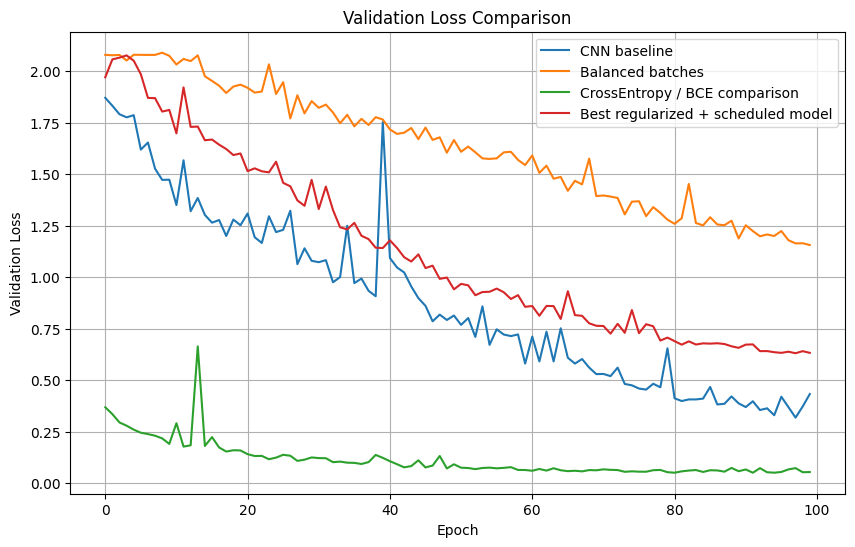

In [19]:
histories = {
    "CNN baseline": baseline_history,
    "Balanced batches": balanced_history,
    "CrossEntropy / BCE comparison": bce_history,
    "Best regularized + scheduled model": best_history
}

plt.figure(figsize=(10, 6))

for name, history in histories.items():

    plt.plot(
        history["val_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()

plt.show()
